# Anomaly Detection: Predictive Maintenance for a Factory Machine

This notebook is a self-made practice project on **anomaly detection with a Gaussian model**,
built while studying the topic from Andrew Ng's Machine Learning Specialization (Course 3, Week 1).
The algorithm and workflow follow the same idea as that lab, but every line of code below is
written from scratch and the whole thing runs on a **brand-new, synthetically generated dataset**
about a completely different scenario: catching a failing bearing on a factory machine before it
actually breaks, instead of catching failing web servers.

Everything here is self-contained (no external `utils.py` or course files are needed), so this
notebook can be run top to bottom and pushed straight to GitHub.

## Outline
- [1 - Packages](#1)
- [2 - Problem: catching a failing machine early](#2)
  - [2.1 Dataset: bearing vibration & temperature](#2.1)
  - [2.2 Fitting a Gaussian distribution](#2.2)
  - [2.3 Choosing a decision threshold with F1 score](#2.3)
  - [2.4 Flagging the outliers](#2.4)
- [3 - Scaling up: an 11-sensor production line](#3)
- [4 - Takeaways](#4)


<a name="1"></a>
## 1 - Packages

Just the basics: `numpy` for the math, `matplotlib` for plotting. `numpy`'s new `Generator`
API (`default_rng`) is used to create reproducible synthetic sensor data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)

<a name="2"></a>
## 2 - Problem: catching a failing machine early

Imagine you maintain a machine on a factory floor and two sensors are bolted to its main
bearing:

* **vibration** (mm/s), how much the bearing shakes as it spins
* **temperature** (°C), how hot the bearing runs

Under normal operation both readings hover in a tight, predictable range. When a bearing starts
to wear out, it tends to run hotter and shakier than usual, but "unusual" is a matter of degree,
not a hard cutoff, which is exactly the kind of problem a Gaussian anomaly detector is good at.

The plan is the same as the classic server-monitoring version of this exercise:

1. Fit a Gaussian distribution to a training set that is assumed to be (almost) all normal
   operation.
2. Score a labelled cross-validation set with that distribution.
3. Pick the probability threshold $\varepsilon$ that gives the best F1 score on the
   cross-validation set.
4. Anything scoring below $\varepsilon$ gets flagged as an anomaly.

<a name="2.1"></a>
### 2.1 Dataset: bearing vibration & temperature

Since this is a from-scratch project rather than a real maintenance log, the cell below
**generates** a training set (mostly normal readings) and a labelled cross-validation set
(mostly normal, plus a handful of simulated bearing faults) using a fixed random seed so the
results are reproducible.

In [2]:
def generate_bearing_data(seed=42):
    '''Synthetic vibration/temperature readings for one machine bearing.'''
    rng = np.random.default_rng(seed)

    # --- Training set: assumed to be (almost) all normal operation ---
    n_train = 300
    mean_normal = np.array([4.5, 65.0])          # [vibration mm/s, temperature C]
    cov_normal = np.array([[0.60, 0.35],
                            [0.35, 3.20]])
    X_train = rng.multivariate_normal(mean_normal, cov_normal, n_train)

    # --- Cross-validation set: mostly normal, plus a few labelled faults ---
    n_val_normal = 90
    X_val_normal = rng.multivariate_normal(mean_normal, cov_normal, n_val_normal)
    y_val_normal = np.zeros(n_val_normal)

    n_val_anom = 10
    # Faulty bearings run hotter and shakier on average, but with enough spread
    # that a few faults land close to normal territory -- real sensor noise
    # rarely separates as cleanly as a toy example would like.
    mean_anom = np.array([6.0, 72.0])
    cov_anom = cov_normal * 2.0 + np.array([[0.3, 0.0], [0.0, 0.3]])
    X_val_anom = rng.multivariate_normal(mean_anom, cov_anom, n_val_anom)
    y_val_anom = np.ones(n_val_anom)

    X_val = np.vstack([X_val_normal, X_val_anom])
    y_val = np.concatenate([y_val_normal, y_val_anom])

    perm = rng.permutation(len(X_val))
    return X_train, X_val[perm], y_val[perm]


X_train, X_val, y_val = generate_bearing_data()

#### A quick look at the data

Same habit as always when meeting a new dataset: print a few rows and check the shapes.

In [3]:
print("First 5 rows of X_train (vibration mm/s, temperature C):\n", X_train[:5])
print("\nFirst 5 rows of X_val:\n", X_val[:5])
print("\nFirst 5 labels of y_val (1 = anomaly):\n", y_val[:5])

First 5 rows of X_train (vibration mm/s, temperature C):
 [[ 3.8048 65.6458]
 [ 5.3711 66.2487]
 [ 3.0785 61.6421]
 [ 4.2969 65.2592]
 [ 3.8667 65.0532]]

First 5 rows of X_val:
 [[ 7.666  76.5054]
 [ 2.4743 63.3767]
 [ 3.3686 66.2678]
 [ 4.2178 65.8936]
 [ 5.3094 64.7181]]

First 5 labels of y_val (1 = anomaly):
 [1. 0. 0. 0. 0.]


In [4]:
print('Shape of X_train:', X_train.shape)
print('Shape of X_val:  ', X_val.shape)
print('Shape of y_val:  ', y_val.shape)

Shape of X_train: (300, 2)
Shape of X_val:   (100, 2)
Shape of y_val:   (100,)


#### Visualize the training data

With only two features, a scatter plot shows the whole picture.

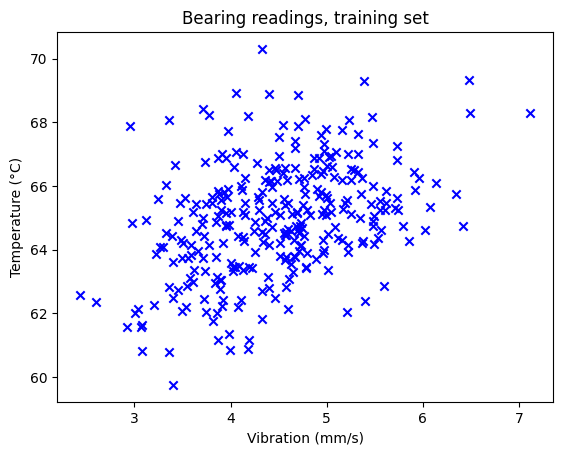

In [5]:
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b')
plt.title("Bearing readings, training set")
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Temperature (\N{DEGREE SIGN}C)")
plt.show()

<a name="2.2"></a>
### 2.2 Fitting a Gaussian distribution

For each feature $x_i$, the Gaussian model needs a mean $\mu_i$ and a variance $\sigma_i^2$:

$$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp\left({ - \frac{(x - \mu)^2}{2 \sigma ^2} }\right)$$

Given a training set $\{x^{(1)}, \dots, x^{(m)}\}$, the maximum-likelihood estimates are just the
sample mean and sample variance of each feature:

$$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)} \qquad\qquad \sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

`estimate_gaussian` below computes both, vectorized over all features at once with
`np.mean(..., axis=0)`.

In [6]:
def estimate_gaussian(X):
    '''
    Calculates the mean and variance of every feature in X.

    Args:
        X (ndarray): (m, n) data matrix

    Returns:
        mu  (ndarray): (n,) mean of every feature
        var (ndarray): (n,) variance of every feature
    '''
    mu = np.mean(X, axis=0)
    var = np.mean((X - mu) ** 2, axis=0)
    return mu, var


mu, var = estimate_gaussian(X_train)
print("Mean of each feature:    ", mu)
print("Variance of each feature:", var)

Mean of each feature:     [ 4.4726 64.963 ]
Variance of each feature: [0.5945 3.1243]


To turn the per-feature $\mu$ and $\sigma^2$ into a single probability for a 2-D (or n-D)
point, treat the features as independent and multiply their individual densities together:
that's exactly what a multivariate Gaussian with a **diagonal** covariance matrix does:

$$ p(x) = \prod_{i=1}^{n} p(x_i ; \mu_i, \sigma_i^2) = \frac{1}{(2\pi)^{n/2}\lvert\Sigma\rvert^{1/2}}
\exp\left(-\tfrac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right), \qquad \Sigma = \text{diag}(\sigma_1^2, \dots, \sigma_n^2)$$

`multivariate_gaussian` below implements this in vectorized form so it can score a whole matrix
of examples in one call.

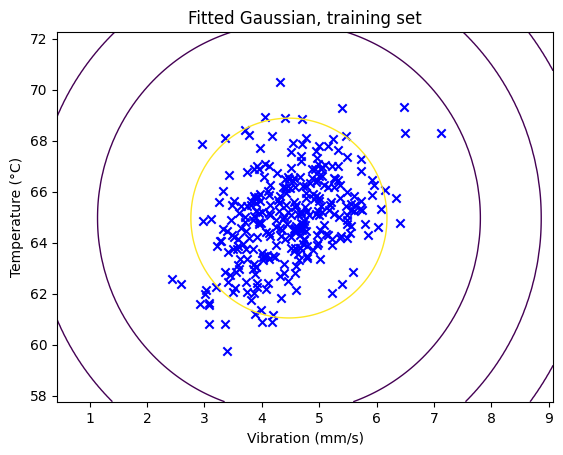

In [7]:
def multivariate_gaussian(X, mu, var):
    '''
    Computes the density of a diagonal-covariance multivariate Gaussian
    at each row (example) of X.

    Args:
        X   (ndarray): (m, n) data matrix
        mu  (ndarray): (n,)   mean of every feature
        var (ndarray): (n,) variance of every feature, OR an (n, n) covariance matrix

    Returns:
        p (ndarray): (m,) density of every example
    '''
    k = mu.shape[0]
    if var.ndim == 1:
        var = np.diag(var)

    X_centered = X - mu
    p = (2 * np.pi) ** (-k / 2) * np.linalg.det(var) ** (-0.5) * \
        np.exp(-0.5 * np.sum(X_centered @ np.linalg.pinv(var) * X_centered, axis=1))
    return p


def visualize_fit(X, mu, var, title=""):
    '''Scatter plot of X with contour lines of the fitted Gaussian overlaid.'''
    x1 = np.arange(X[:, 0].min() - 2, X[:, 0].max() + 2, 0.05)
    x2 = np.arange(X[:, 1].min() - 2, X[:, 1].max() + 2, 0.05)
    X1, X2 = np.meshgrid(x1, x2)
    Z = multivariate_gaussian(np.column_stack([X1.ravel(), X2.ravel()]), mu, var)
    Z = Z.reshape(X1.shape)

    plt.scatter(X[:, 0], X[:, 1], marker='x', c='b')
    if not np.any(np.isinf(Z)):
        levels = 10.0 ** np.arange(-20, 0, 3)
        plt.contour(X1, X2, Z, levels=levels, linewidths=1)
    plt.title(title)
    plt.xlabel("Vibration (mm/s)")
    plt.ylabel("Temperature (\N{DEGREE SIGN}C)")


p = multivariate_gaussian(X_train, mu, var)
visualize_fit(X_train, mu, var, title="Fitted Gaussian, training set")
plt.show()

Most of the training points sit in the region of highest probability, which is what a
"mostly normal operation" training set should look like once the Gaussian is fit correctly.

<a name="2.3"></a>
### 2.3 Choosing a decision threshold with F1 score

The Gaussian gives a probability $p(x)$ for every point, but a probability alone isn't a
decision. A **threshold** $\varepsilon$ is still needed: points with $p(x) < \varepsilon$ get
flagged as anomalies.

Because the labelled anomalies are rare, plain accuracy is a bad way to pick $\varepsilon$ (a
detector that never flags anything would still look "accurate"). Instead, `select_threshold`
sweeps many candidate values of $\varepsilon$ over the cross-validation set and keeps the one
with the best **F1 score**:

$$prec = \frac{tp}{tp+fp} \qquad rec = \frac{tp}{tp+fn} \qquad F_1 = \frac{2 \cdot prec \cdot rec}{prec + rec}$$

where $tp$, $fp$, $fn$ are true/false positives and false negatives against the ground-truth
labels `y_val`.

In [8]:
def select_threshold(y_val, p_val):
    '''
    Finds the epsilon that gives the best F1 score on a labelled validation set.

    Args:
        y_val (ndarray): ground-truth labels (1 = anomaly) for the validation set
        p_val (ndarray): Gaussian probability for every validation example

    Returns:
        best_epsilon (float): threshold that maximizes F1
        best_F1 (float):      the F1 score achieved at best_epsilon
    '''
    best_epsilon = 0
    best_F1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        predictions = (p_val < epsilon)

        tp = np.sum((predictions == 1) & (y_val == 1))
        fp = np.sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        F1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon

    return best_epsilon, best_F1


p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on cross-validation set:            %f' % F1)

Best epsilon found using cross-validation: 1.136184e-04
Best F1 on cross-validation set:            0.823529


<a name="2.4"></a>
### 2.4 Flagging the outliers

With $\mu$, $\sigma^2$ and $\varepsilon$ all in hand, running the detector on the training set
and circling whatever falls below the threshold shows which readings the model considers
suspicious.

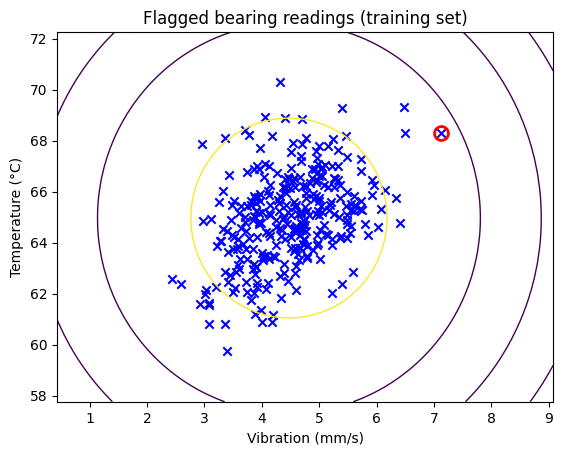

Flagged 1 out of 300 training readings as anomalies.


In [9]:
outliers = p < epsilon

visualize_fit(X_train, mu, var, title="Flagged bearing readings (training set)")
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize=10, markerfacecolor='none', markeredgewidth=2)
plt.show()

print(f"Flagged {outliers.sum()} out of {len(X_train)} training readings as anomalies.")

<a name="3"></a>
## 3 - Scaling up: an 11-sensor production line

Two sensors make a nice picture, but a real production line is instrumented far more heavily.
This section repeats the exact same recipe (estimate Gaussian, score, pick $\varepsilon$) on a
synthetic dataset with **11 sensor channels** per example (vibration, temperature, motor current,
voltage, RPM, hydraulic pressure, acoustic noise, humidity, torque, coolant flow rate, and oil
level), which is harder to visualize but no harder to compute.

In [10]:
def generate_production_line_data(seed=7):
    '''Synthetic 11-sensor readings from a production-line machine.'''
    rng = np.random.default_rng(seed)

    feature_names = ['vibration_mm_s', 'temperature_C', 'current_A', 'voltage_V',
                      'rpm', 'pressure_bar', 'noise_dB', 'humidity_pct',
                      'torque_Nm', 'flow_rate_Lpm', 'oil_level_pct']
    n_features = len(feature_names)

    mean = np.array([4.5, 65.0, 12.0, 220.0, 1450.0, 5.5, 68.0, 45.0, 30.0, 15.0, 80.0])
    std = np.array([0.8, 3.2, 1.1, 4.0, 25.0, 0.6, 3.0, 5.0, 2.5, 1.5, 4.0])

    n_train = 1000
    X_train_high = rng.normal(mean, std, size=(n_train, n_features))

    n_val_normal = 90
    X_val_normal = rng.normal(mean, std, size=(n_val_normal, n_features))
    y_val_normal = np.zeros(n_val_normal)

    n_val_anom = 15
    X_val_anom = rng.normal(mean, std, size=(n_val_anom, n_features))
    for i in range(n_val_anom):
        n_bad = rng.integers(2, 5)
        bad_idx = rng.choice(n_features, size=n_bad, replace=False)
        X_val_anom[i, bad_idx] += (rng.choice([-1, 1], size=n_bad)
                                    * std[bad_idx] * rng.uniform(4, 7, n_bad))
    y_val_anom = np.ones(n_val_anom)

    X_val_high = np.vstack([X_val_normal, X_val_anom])
    y_val_high = np.concatenate([y_val_normal, y_val_anom])

    perm = rng.permutation(len(X_val_high))
    return X_train_high, X_val_high[perm], y_val_high[perm], feature_names


X_train_high, X_val_high, y_val_high, feature_names = generate_production_line_data()

print('Shape of X_train_high:', X_train_high.shape)
print('Shape of X_val_high:  ', X_val_high.shape)
print('Shape of y_val_high:  ', y_val_high.shape)
print('Sensors:', feature_names)

Shape of X_train_high: (1000, 11)
Shape of X_val_high:   (105, 11)
Shape of y_val_high:   (105,)
Sensors: ['vibration_mm_s', 'temperature_C', 'current_A', 'voltage_V', 'rpm', 'pressure_bar', 'noise_dB', 'humidity_pct', 'torque_Nm', 'flow_rate_Lpm', 'oil_level_pct']


In [11]:
# Same three-step recipe as before, just with 11 features instead of 2
mu_high, var_high = estimate_gaussian(X_train_high)

p_high = multivariate_gaussian(X_train_high, mu_high, var_high)
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('Best epsilon found using cross-validation: %e' % epsilon_high)
print('Best F1 on cross-validation set:            %f' % F1_high)
print('# anomalies found in training set:          %d' % np.sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 3.251278e-13
Best F1 on cross-validation set:            0.652174
# anomalies found in training set:          118


With 11 correlated-looking-but-independent sensors, a diagonal-covariance Gaussian has to
work harder to separate the faults from normal noise, so it's normal for the F1 score here to be
lower than in the 2-D case above; the same pattern shows up in the original two-feature vs.
eleven-feature server dataset this project was inspired by.

<a name="4"></a>
## 4 - Takeaways

* A Gaussian anomaly detector needs almost no labelled data to train; only the handful of
  labelled examples used to pick $\varepsilon$ actually need labels.
* Treating features as independent (diagonal covariance) is simple and fast, but it can miss
  anomalies that only show up as an unusual *combination* of features rather than an unusual
  single feature. A natural next step is to try a **full covariance matrix** so the model can
  learn correlations between sensors.
* Other good follow-ups for this project: run it on a real public dataset (e.g. the Numenta
  Anomaly Benchmark, or a Kaggle machine-sensor dataset), compare against `sklearn`'s
  `EllipticEnvelope` or `IsolationForest`, and plot precision/recall curves instead of a single
  F1 number.
